# 网络中的网络(NiN)

卷积层的输入和输出由四维张量组成，张量的每个轴分别对应样本、通道、高度和宽度。 

另外，全连接层的输入和输出通常是分别对应于样本和特征的二维张量。 

NiN的想法是在每个像素位置（针对每个高度和宽度）应用一个全连接层（这个换成了$1 \times 1$卷积层）。

## 构建模型块

In [2]:
import torch
from torch import nn
from d2l import torch as d2l


def nin_block(in_channels, out_channels, kernel_size, strides, padding):  # 一个NiN块包括一个卷积层和两个1x1卷积层，代替全连接层
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, strides, padding),
        nn.ReLU(),
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU(),  # 1*1卷积层，输出通道数与输入通道数相同，本质上是做通道上的空间特征融合
        nn.Conv2d(out_channels, out_channels, kernel_size=1), nn.ReLU())

NiN使用窗口形状为$11 \times 11, 5 \times 5, 3 \times 3$的卷积层，输出的通道与AlexNet中的相同。每个NiN块以后有一个最大的池化层，池化层的窗口形状为$3 \times 3$， strides为2

NiN块的模型如下， 输出的通道等于标签类别的数量。最后放一个全局平均池化层，生成一个对数几率（未经 Softmax 归一化的原始输出）。

其实是将最后一个卷积层的每个通道（对应一个类别）的空间信息平均为一个数值，直接作为该类别的对数几率输出

## 模型构建

In [ ]:
net = nn.Sequential(
    nin_block(1, 96, kernel_size=11, strides=4, padding=0),
    nn.MaxPool2d(3, stride=2),
    nin_block(96, 256, kernel_size=5, strides=1, padding=2),
    nn.MaxPool2d(3, stride=2),
    nin_block(256, 384, kernel_size=3, strides=1, padding=1),
    nn.MaxPool2d(3, stride=2),
    nn.Dropout(0.5),
    # 标签类别数是10
    nin_block(384, 10, kernel_size=3, strides=1, padding=1),
    nn.AdaptiveAvgPool2d((1, 1)),  # 自适应平均池化层，无论输入特征图的尺寸是多少，都能输出指定尺寸的特征图。
    # 将四维的输出转成二维的输出，其形状为(批量大小,10)
    nn.Flatten())

创建一个数据样本来查看每个块的形状

In [4]:
X = torch.rand(size=(1, 1, 224, 224))
for layer in net:
    X = layer(X)
    print(layer.__class__.__name__,'output shape:\t', X.shape)

Sequential output shape:	 torch.Size([1, 96, 54, 54])
MaxPool2d output shape:	 torch.Size([1, 96, 26, 26])
Sequential output shape:	 torch.Size([1, 256, 26, 26])
MaxPool2d output shape:	 torch.Size([1, 256, 12, 12])
Sequential output shape:	 torch.Size([1, 384, 12, 12])
MaxPool2d output shape:	 torch.Size([1, 384, 5, 5])
Dropout output shape:	 torch.Size([1, 384, 5, 5])
Sequential output shape:	 torch.Size([1, 10, 5, 5])
AdaptiveAvgPool2d output shape:	 torch.Size([1, 10, 1, 1])
Flatten output shape:	 torch.Size([1, 10])


## 训练模型

training on cuda:0


RuntimeError: CUDA out of memory. Tried to allocate 70.00 MiB (GPU 0; 2.00 GiB total capacity; 658.48 MiB already allocated; 56.39 MiB free; 686.00 MiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

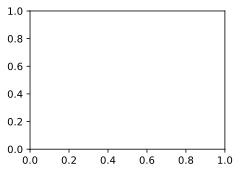

In [7]:
lr, num_epochs, batch_size = 0.1, 10, 64
d2l.get_dataloader_workers = lambda: 0
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=224)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())